In [1]:
!pip install pandas

In [2]:
!pip install seaborn

In [3]:
import pandas as pd
import sqlite3
from sqlite3 import Error
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
def create_connection(path):
    connection = None
    try:
        connection = sqlite3.connect(path)
    except Error as e:
        print(f"The error {e} occured")
    return connection

connection = create_connection("../checking-logs.sqlite")

In [5]:
query = """
SELECT uid, DATE(timestamp) AS timestamp, numTrials
FROM checker
WHERE uid LIKE 'user_%' AND labname = 'project1' AND status = 'ready' 
"""

df = pd.read_sql(query, connection)
df["timestamp"] = pd.to_datetime(df["timestamp"])

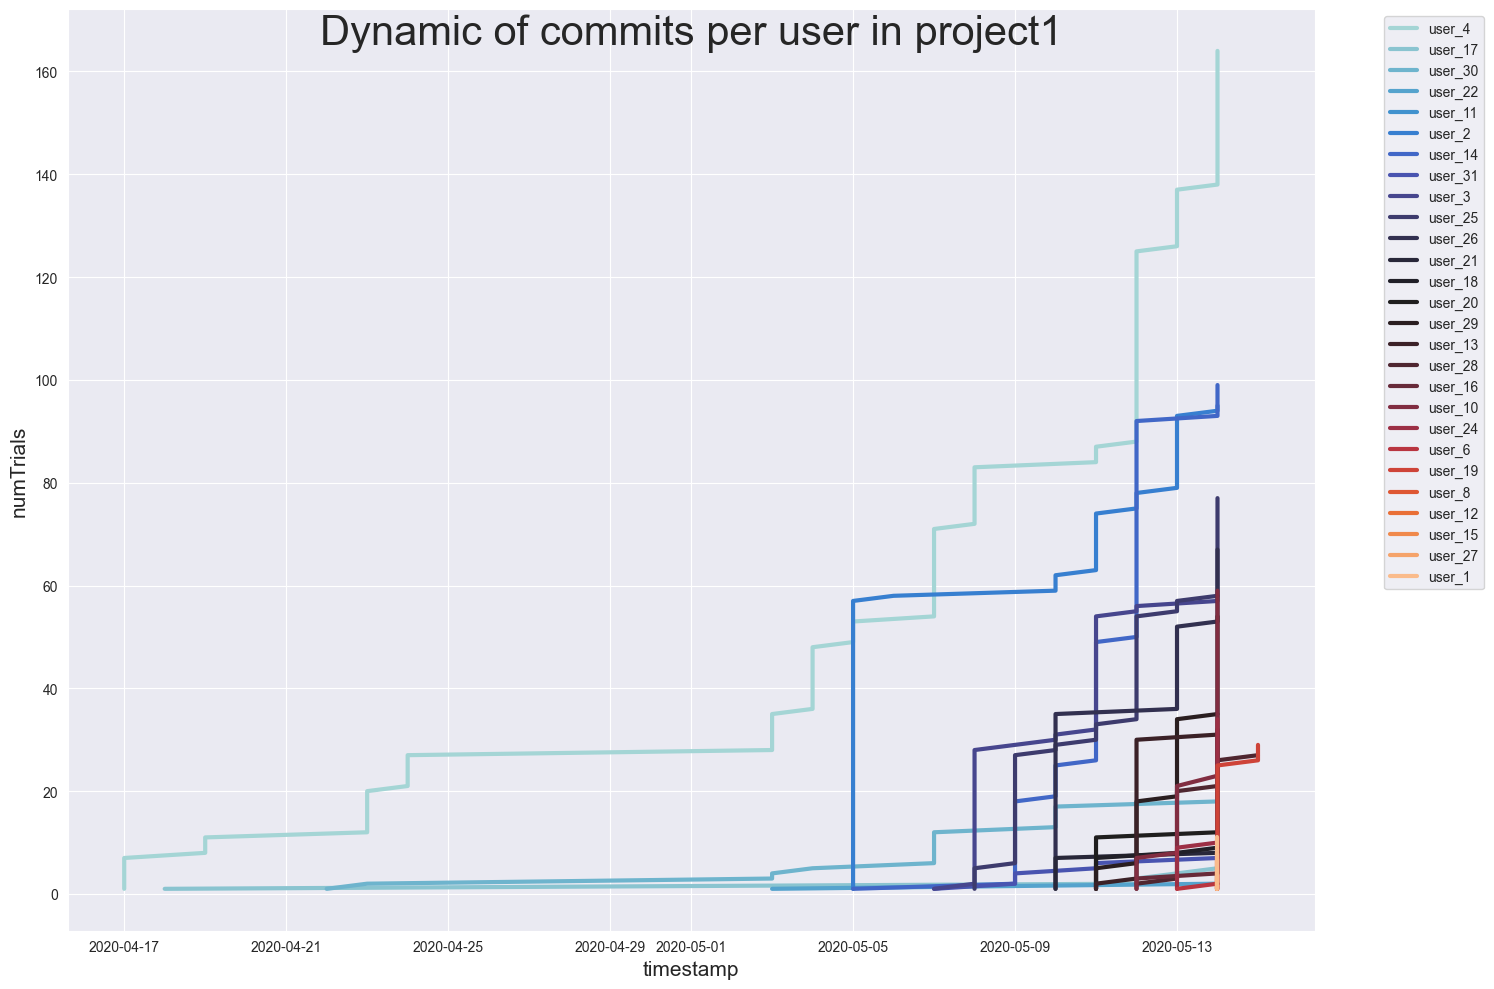

In [6]:
plt.figure(figsize=(15, 10))
sns.set_style("darkgrid")
sns.lineplot(df, x = "timestamp", y = "numTrials", hue= "uid", linewidth=3, estimator=None, errorbar=None, palette="icefire")
plt.title("Dynamic of commits per user in project1", fontsize=30, pad=-25)
plt.xlabel("timestamp", fontsize=15)
plt.ylabel("numTrials", fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

In [7]:
connection.close()

* Which user was the leader in the number of commits almost all of the time? The answer: user_4.
* Which user was the leader for only a short period of time? The answer: user_2.